# Week 1: Basic training and pipelines

There are **two tasks** in this notebook:
1. basic training and evaluation of an MNIST model,
2. examples of model pipelines.

**NOTE:** complete the exercise without installing additional dependencies. `pyproject.toml` specifies everything you need: torch, numpy, matplotlib, sklearn, pandas.

When you're done export the notebook as pdf (with all output cells) and submit it.

## Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

## Data loading

In [2]:
# Data transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load training data
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Download and load test data
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:01<00:00, 9430359.60it/s] 


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 256091.63it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 2393836.36it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 17672104.61it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



## Model definition

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## Training setup

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

## Training loop 

**TODO (1/4)**

This training loop doesn't implement any loss over time tracking. Add it.

In [12]:
train_losses = []

for epoch in tqdm(range(num_epochs), desc='Training'):
    model.train()

    epoch_loss = 0.0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)

    print(f'Epoch {epoch + 1}: Loss = {epoch_loss:.4f}')

Training:  20%|██        | 1/5 [00:14<00:58, 14.68s/it]

Epoch 1: Loss = 0.0225


Training:  40%|████      | 2/5 [00:28<00:42, 14.29s/it]

Epoch 2: Loss = 0.0232


Training:  60%|██████    | 3/5 [00:43<00:28, 14.34s/it]

Epoch 3: Loss = 0.0202


Training:  80%|████████  | 4/5 [00:57<00:14, 14.22s/it]

Epoch 4: Loss = 0.0182


Training: 100%|██████████| 5/5 [01:11<00:00, 14.26s/it]

Epoch 5: Loss = 0.0183


## Evaluation

**TODO (2/4)**

Right now, we don't know how well the model performs.
Using the `test_loader` compute the accuracy:
- average for the entire test set and
- per class.

Additionally, plot a confusion matrix.

Overall accuracy: 0.9914
Class 0: 0.9949
Class 1: 0.9965
Class 2: 0.9971
Class 3: 0.9931
Class 4: 0.9857
Class 5: 0.9899
Class 6: 0.9948
Class 7: 0.9796
Class 8: 0.9949
Class 9: 0.9871


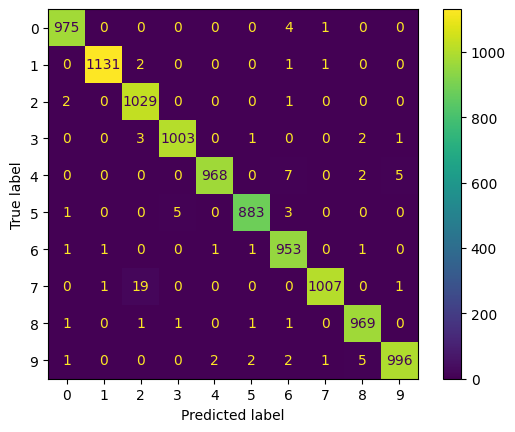

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for data, target in test_loader:
        pred = model(data.to(device)).argmax(1).cpu()
        y_true.extend(target.numpy())
        y_pred.extend(pred.numpy())

# Average accuracy
print(f"Overall accuracy: {accuracy_score(y_true, y_pred):.4f}")

# Accuracy per class
report = classification_report(y_true, y_pred, output_dict=True)
for i in range(10):
    print(f"Class {i}: {report[str(i)]['recall']:.4f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()

## Data producers

**TODO (3/4)**

Data production can be divided into: 1) deliberate and incidental; 2) voluntary and harvested. For each combination, provide an example.

|           | deliberate   | incidental       | 
|-----------|--------------|------------------|
| voluntary | Survey       | Social media     |
| harvested | Search query | Website tracking |

## Pipelines

**TODO (4/4)**

Recall the pipeline from the first lecture.
For each of the stages (blocks -- there seven and two environemnt ones) list **three** parties/environments that could be classified into them. Justify each with one sentennce.

1. Data records
    - End users: Users generate individual records through interactions, uploads, or other activities, like when we seach on Google or upload photos on Instagram.
    - IoT/sensor operators: Sensors produce individual measurements such as locations or telemetry.
    - Third-party data providers: External organizations can provide individual records collected through their own services, like Meta collects user's preference.
2. Dataset
    - Annotation providers: Annotation companies like Scale AI, label raw records so that they can be used for supervised learning.
    - Data curators: For example, the ImageNet team collected and organized images into a structured dataset.
    - Dataset publishers: Organizations such as research institutes package and publish datasets for downstream use.
3. Data repository
    - Hugging Face hosts datasets that developers can discover and retrieve.
    - Kaggle provides storage and distribution of datasets contributed by organizations and users.
    - Cloud storage providers like AWS, can host datasets used by ML pipelines.
4. Training
    - AI company: For instance like Open AI or Anthropic, AI companies can design and execute the process that converts training data into a trained model.
    - Research labs: Research groups train experimental or production models using their own training pipelines.
    - ML platform providers: Managed ML platforms can execute training jobs on behalf of model developers.
5. Training - Environment & dependency providers
    - GPU/cloud providers: Providers such as NVIDIA, AWS or Azure supply the compute infrastructure on which training runs.
    - ML framework providers: PyTorch or TensorFlow developers provide core software dependencies used during training.
    - OS providers: Such as Ubuntu, the operating system on which the training software, drivers, and ML dependencies can run.
6. Model
    - Foundation-model providers: Organizations such as OpenAI, Google, or Meta develop models that may subsequently be used by others.
    - Fine-tuning providers: A party can modify an existing model and thereby produce a new downstream model artifact.
    - Individual model developers: The developers like researchers, cna produce the trained weights directly.
7. Model repository
    - The Hugging Face Hub stores and distributes trained model artifacts to downstream users.
    - GitHub repositories can distribute model weights, configurations, and associated files.
    - Cloud artifact registries like AWS or Azure can store and version models before deployment
8. Inference
    - Application/service providers: Applications invoke deployed models on user inputs to generate predictions or outputs, for example like ChatGPT.
    - Model API providers: API providers execute inference remotely and return model outputs to clients.
    - Edge-device operators:  Inference can be run locally on phones, vehicles, cameras, or other edge devices.
9. Inference - Environment & dependency providers
    - Cloud compute providers: Cloud providers supply the CPUs/GPUs and infrastructure on which inference executes.
    - Container/package providers: Docker registries and package repositories provide software dependencies required by inference services.
    - Inference runtime providers: Software such as ONNX Runtime or TensorRT provides the runtime needed to execute models.